# 01 OpenCV Basics

Dieses Notebook bearbeitet die ersten praktischen Schritte der OpenCV-Basics. Ein Bild wird mit OpenCV geladen, mit `matplotlib` angezeigt und schrittweise untersucht.

## Goal

Ziel ist es, ein Bild mit OpenCV zu laden, korrekt anzuzeigen und die grundlegende Bildstruktur zu verstehen. Zusätzlich wird ein Farbbild in ein Grauwertbild umgewandelt.

## Theory

OpenCV liest Farbbilder standardmäßig im BGR-Format ein. Das bedeutet, dass die Kanäle in der Reihenfolge Blau, Grün, Rot gespeichert sind. `matplotlib` erwartet dagegen RGB, also Rot, Grün, Blau. Deshalb wird das Bild vor der korrekten Anzeige nach RGB konvertiert.

Ein Farbbild benötigt drei Kanäle, weil für jeden Pixel getrennte Farbanteile gespeichert werden. Ein Grauwertbild benötigt nur einen Intensitätskanal, da jeder Pixel nur eine Helligkeit zwischen dunkel und hell beschreibt.

## Method

Zuerst werden die benötigten Bibliotheken importiert und kleine Hilfsfunktionen für die Anzeige vorbereitet. Danach wird ein Beispielbild aus dem `data`-Ordner mit `cv2.imread()` geladen, von BGR nach RGB umgewandelt und angezeigt.

Anschließend werden die Bildstruktur, ein Beispielpixel und die Grauwertdarstellung untersucht.

## Implementation

### Aufgabe 1: Bild laden

In diesem Abschnitt wird das erste Bild geladen und angezeigt. Weitere Auswertungen werden danach Schritt für Schritt ergänzt.

In [71]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [72]:
DATA_DIR = Path("../data")
IMAGE_PATH = DATA_DIR / "test_image_1.jpg"

In [73]:
def show_gray(image, title="Grayscale image"):
    # Display a grayscale image without axes.
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_rgb(image, title="RGB image"):
    # Display an RGB image without axes.
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

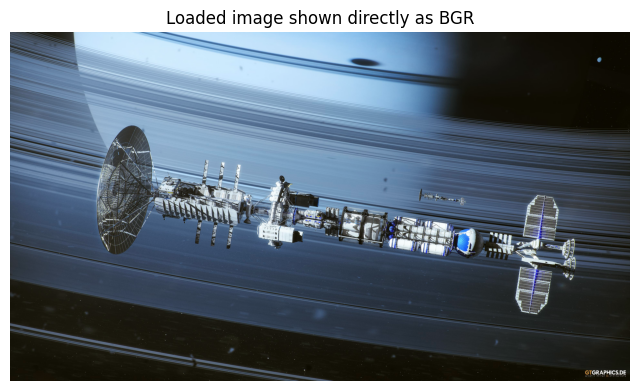

Image loaded from: ..\data\test_image_1.jpg
Image shape: (2160, 3840, 3)


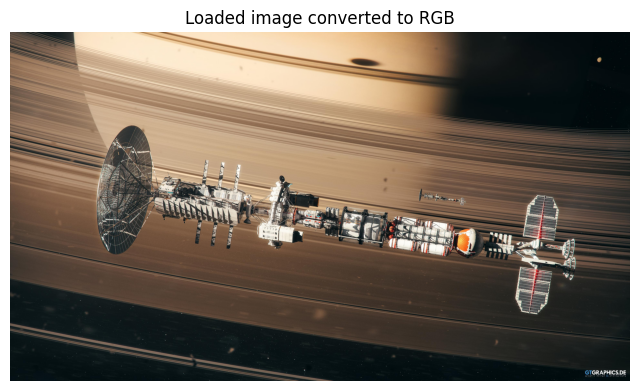

In [74]:
image_bgr = cv2.imread(str(IMAGE_PATH))

if image_bgr is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

# Show the loaded BGR image directly to make the color order visible.
plt.figure(figsize=(8, 6))
plt.imshow(image_bgr)
plt.title("Loaded image shown directly as BGR")
plt.axis("off")
plt.show()

# Convert BGR to RGB before displaying with matplotlib.
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Image loaded from: {IMAGE_PATH}")
print(f"Image shape: {image_rgb.shape}")

show_rgb(image_rgb, "Loaded image converted to RGB")

### Aufgabe 2: Datenstruktur des Bildes analysieren

Ein Bild wird in Python als NumPy-Array gespeichert. Die Form (`shape`) beschreibt die Höhe, Breite und bei Farbbildern die Anzahl der Farbkanäle.

Der Datentyp (`dtype`) zeigt, wie die einzelnen Pixelwerte gespeichert werden.

In [75]:
# Read basic image information from the NumPy array.
height, width, channels = image_bgr.shape

print(f"Height: {height} pixels")
print(f"Width: {width} pixels")
print(f"Channels: {channels}")
print(f"Data type: {image_bgr.dtype}")

Height: 2160 pixels
Width: 3840 pixels
Channels: 3
Data type: uint8


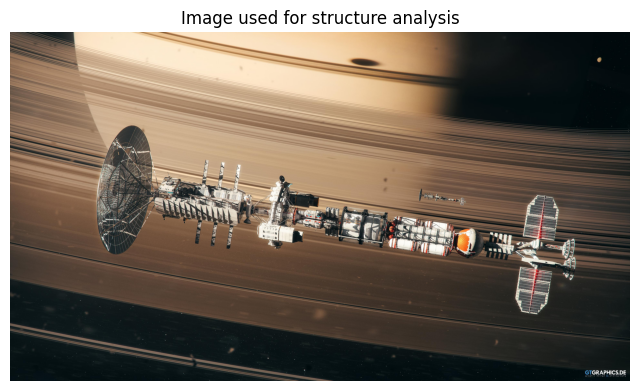

In [76]:
# Show the same image again as visual context for the printed values.
show_rgb(image_rgb, "Image used for structure analysis")

### Aufgabe 3: Einzelne Pixelwerte analysieren

Ein einzelner Pixel kann über seine Zeilen- und Spaltenposition aus dem Bildarray ausgelesen werden. Bei einem Farbbild besteht ein Pixel aus drei Werten.

Da das Bild mit OpenCV geladen wurde, sind diese Werte in der Reihenfolge BGR gespeichert: Blau, Grün, Rot.

In [77]:
# Choose one pixel near the center of the image.
row = height // 2
col = width // 2

# OpenCV stores color values as BGR.
pixel_bgr = image_bgr[row, col]
blue, green, red = pixel_bgr

print(f"Pixel position: row={row}, col={col}")
print(f"BGR pixel value: {pixel_bgr}")
print(f"Blue: {blue}, Green: {green}, Red: {red}")

Pixel position: row=1080, col=1920
BGR pixel value: [128 166 201]
Blue: 128, Green: 166, Red: 201


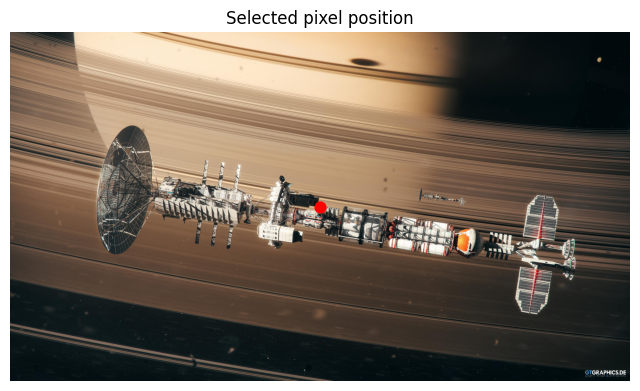

In [78]:
# Mark the selected pixel in the RGB image for easier understanding.
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.scatter(col, row, color="red", s=60)
plt.title("Selected pixel position")
plt.axis("off")
plt.show()

### Aufgabe 4: Grauwertbild erstellen

Als nächster Schritt wird das geladene Farbbild in ein Grauwertbild umgewandelt. Ein Farbbild speichert pro Pixel drei Farbwerte.

Ein Grauwertbild speichert dagegen nur einen Wert pro Pixel, nämlich die Helligkeit. Dadurch geht die Farbinformation verloren, aber Formen, Kanten und Helligkeitsunterschiede bleiben sichtbar.

In [79]:
# Convert the OpenCV BGR image to grayscale.
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Color image shape: {image_bgr.shape}")
print(f"Grayscale image shape: {image_gray.shape}")
print(f"Grayscale data type: {image_gray.dtype}")

Color image shape: (2160, 3840, 3)
Grayscale image shape: (2160, 3840)
Grayscale data type: uint8


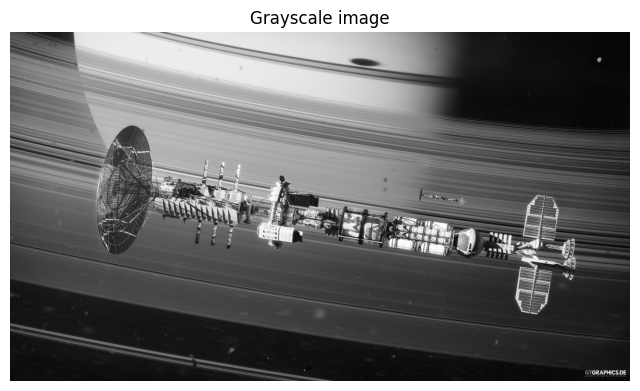

In [80]:
# Show the grayscale image with a grayscale colormap.
show_gray(image_gray, "Grayscale image")

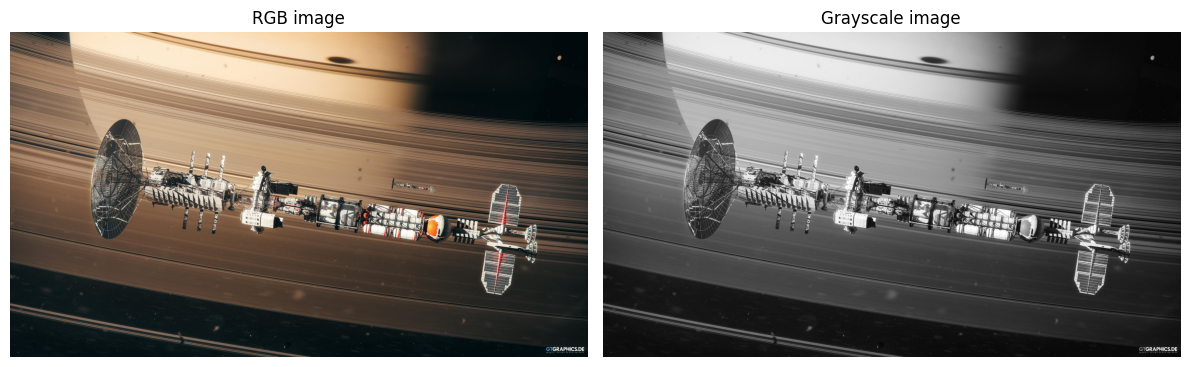

In [81]:
# Compare the RGB image and the grayscale image side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("RGB image")
axes[0].axis("off")

axes[1].imshow(image_gray, cmap="gray")
axes[1].set_title("Grayscale image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 5: Grauwert-Histogramm erstellen

Ein Histogramm zeigt, wie oft bestimmte Pixelwerte in einem Bild vorkommen. Bei einem Grauwertbild geht es um die Intensitätswerte von 0 bis 255. Dunkle Bereiche liegen eher links im Histogramm, helle Bereiche eher rechts.

Für diese Aufgabe wird das bereits erzeugte Grauwertbild `image_gray` verwendet.

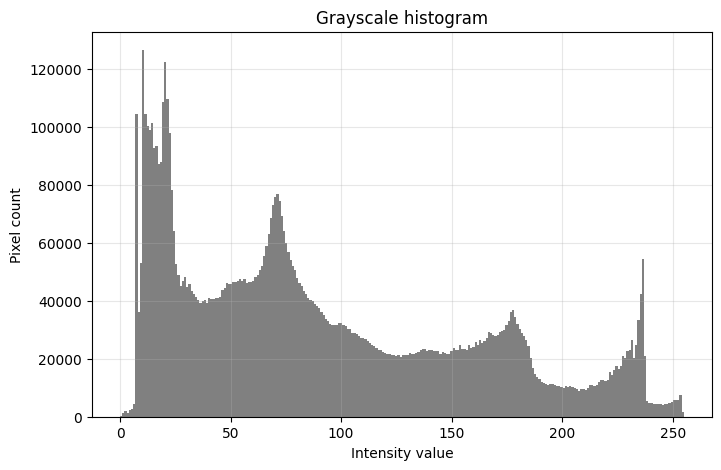

In [82]:
# Plot the grayscale intensity distribution.
plt.figure(figsize=(8, 5))
plt.hist(image_gray.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Grayscale histogram")
plt.xlabel("Intensity value")
plt.ylabel("Pixel count")
plt.grid(alpha=0.3)
plt.show()

### Aufgabe 6: Einfache Schwellwertbildung

Bei der Schwellwertbildung wird ein Grauwertbild in ein Binärbild umgewandelt. Jeder Pixel wird mit einem festen Schwellwert verglichen. Werte über dem Schwellwert werden weiß, Werte darunter werden schwarz.

So kann ein Bild grob in Vordergrund und Hintergrund getrennt werden. Welche Bereiche als Vordergrund gelten, hängt davon ab, ob ein normales oder ein inverses Binärbild verwendet wird.

In [83]:
# Apply a fixed threshold to the grayscale image.
threshold_value = 127
max_value = 255

_, binary_image = cv2.threshold(image_gray, threshold_value, max_value, cv2.THRESH_BINARY)
_, binary_inverse_image = cv2.threshold(image_gray, threshold_value, max_value, cv2.THRESH_BINARY_INV)

print(f"Threshold value: {threshold_value}")

Threshold value: 127


Die folgenden Bilder zeigen das ursprüngliche Grauwertbild, das normale Binärbild und das inverse Binärbild im Vergleich.

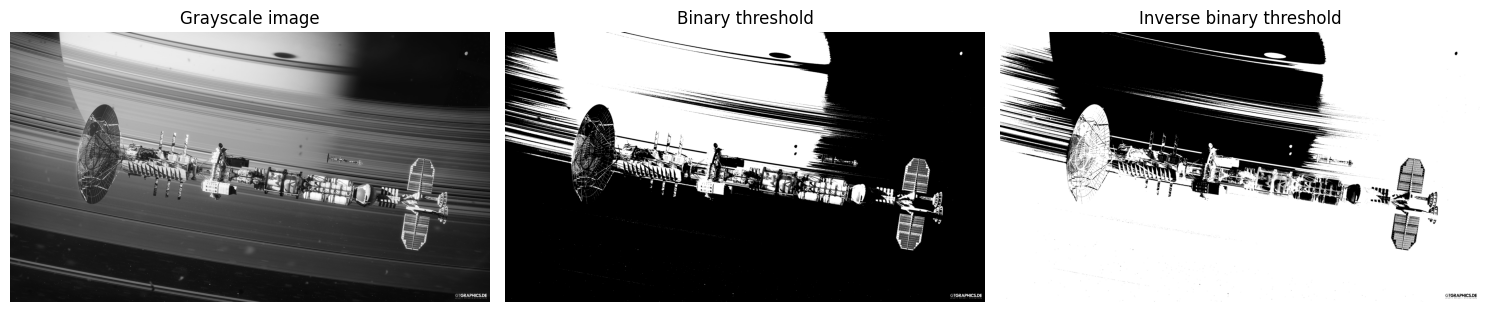

In [84]:
# Show grayscale and thresholded images side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Grayscale image")
axes[0].axis("off")

axes[1].imshow(binary_image, cmap="gray")
axes[1].set_title("Binary threshold")
axes[1].axis("off")

axes[2].imshow(binary_inverse_image, cmap="gray")
axes[2].set_title("Inverse binary threshold")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 7: Einfache Bildglättung

Bildglättung oder Filterung reduziert kleine Störungen im Bild. Dadurch wirken Helligkeitswechsel weicher und zufälliges Bildrauschen kann abgeschwächt werden.

Gaussian Blur glättet Intensitätsübergänge mit einer gewichteten Nachbarschaft. Median Blur ersetzt einen Pixel durch den Median seiner Umgebung und ist deshalb oft nützlich gegen Salt-and-Pepper-Rauschen.

In [85]:
# Apply basic smoothing filters to the grayscale image.
gaussian_blur = cv2.GaussianBlur(image_gray, (5, 5), 0)
median_blur = cv2.medianBlur(image_gray, 5)

Die folgenden Bilder vergleichen das originale Grauwertbild mit den beiden geglätteten Varianten.

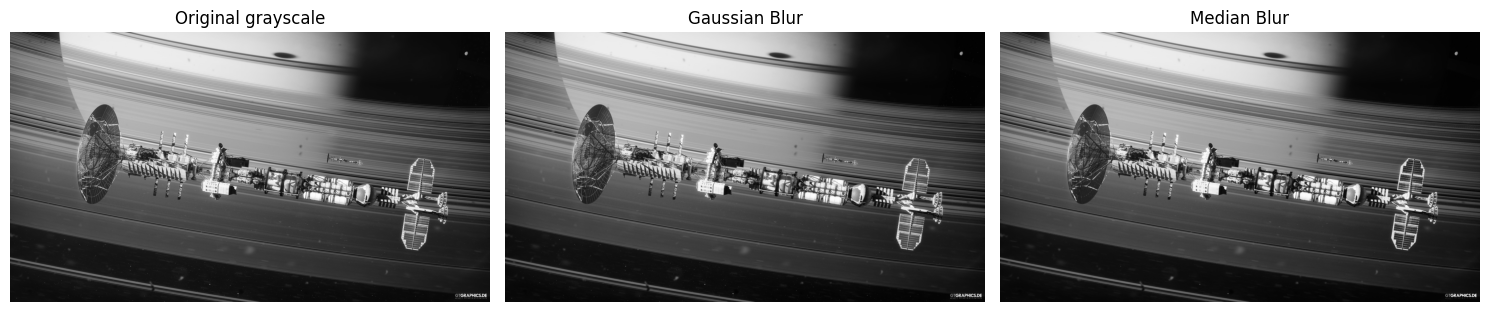

In [86]:
# Show original and smoothed images side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Original grayscale")
axes[0].axis("off")

axes[1].imshow(gaussian_blur, cmap="gray")
axes[1].set_title("Gaussian Blur")
axes[1].axis("off")

axes[2].imshow(median_blur, cmap="gray")
axes[2].set_title("Median Blur")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 8: Einfache Kantenerkennung

Kanten sind Stellen im Bild, an denen sich die Helligkeit stark ändert. Solche Übergänge sind in der Bildverarbeitung wichtig, weil sie häufig Objektgrenzen, Formen oder Strukturen zeigen.

Sobel hebt Intensitätsänderungen in einer Richtung hervor. Sobel X reagiert vor allem auf vertikale Kanten, Sobel Y eher auf horizontale Kanten. Canny kombiniert mehrere Schritte und erzeugt eine sauberere binäre Kantenkarte.

In [87]:
# Apply Sobel edge detection in x and y direction.
sobel_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)

# Convert Sobel results to visible 8-bit images.
sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)

# Apply Canny edge detection.
canny_edges = cv2.Canny(image_gray, 100, 200)

Die folgenden Bilder zeigen das originale Grauwertbild und die erkannten Kanten im Vergleich.

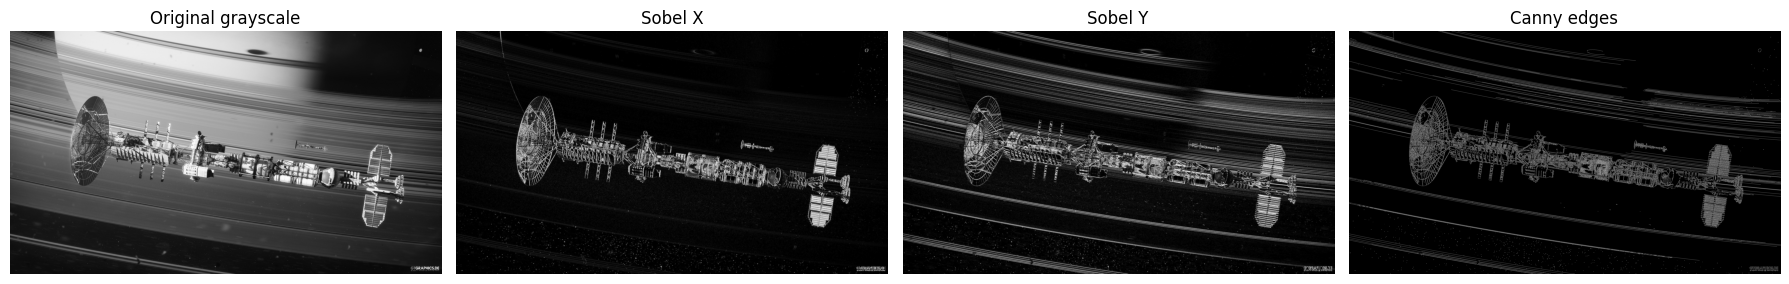

In [88]:
# Show original image and edge detection results side by side.
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Original grayscale")
axes[0].axis("off")

axes[1].imshow(sobel_x_abs, cmap="gray")
axes[1].set_title("Sobel X")
axes[1].axis("off")

axes[2].imshow(sobel_y_abs, cmap="gray")
axes[2].set_title("Sobel Y")
axes[2].axis("off")

axes[3].imshow(canny_edges, cmap="gray")
axes[3].set_title("Canny edges")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 9: Einfache Konturerkennung

Konturen beschreiben zusammenhängende Grenzen von Objekten oder Bildbereichen. In der Bildverarbeitung sind sie nützlich, weil sie Formen und Objektgrenzen kompakt darstellen können.

Für die Konturerkennung werden oft Binärbilder verwendet, weil Vordergrund und Hintergrund dort bereits getrennt sind. Hier werden nur externe Konturen betrachtet.

In [89]:
# Detect external contours in the binary image.
contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on a copy of the RGB image.
contour_image = image_rgb.copy()
cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 2)

print(f"Number of detected contours: {len(contours)}")

Number of detected contours: 6611


Die folgenden Bilder zeigen das Binärbild und das RGB-Bild mit eingezeichneten Konturen im Vergleich.

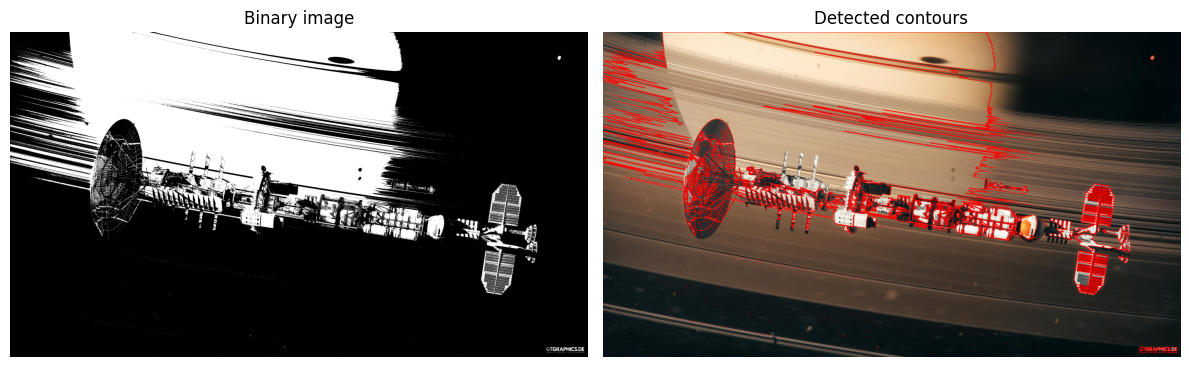

In [90]:
# Show binary image and contour result side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(binary_image, cmap="gray")
axes[0].set_title("Binary image")
axes[0].axis("off")

axes[1].imshow(contour_image)
axes[1].set_title("Detected contours")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 10: Einfache Morphologie

Morphologische Operationen verändern Formen in einem Binärbild. Sie sind nützlich, um kleine Störungen zu entfernen oder Vordergrundbereiche gezielt zu vergrößern.

Erosion verkleinert weiße Vordergrundbereiche und kann kleine weiße Störpixel entfernen. Dilatation vergrößert weiße Vordergrundbereiche und kann kleine Lücken schließen.

In [91]:
# Create a simple morphology kernel.
kernel = np.ones((3, 3), np.uint8)

# Apply erosion and dilation with one iteration.
eroded_image = cv2.erode(binary_image, kernel, iterations=1)
dilated_image = cv2.dilate(binary_image, kernel, iterations=1)

Die folgenden Bilder zeigen das ursprüngliche Binärbild sowie das Ergebnis von Erosion und Dilatation.

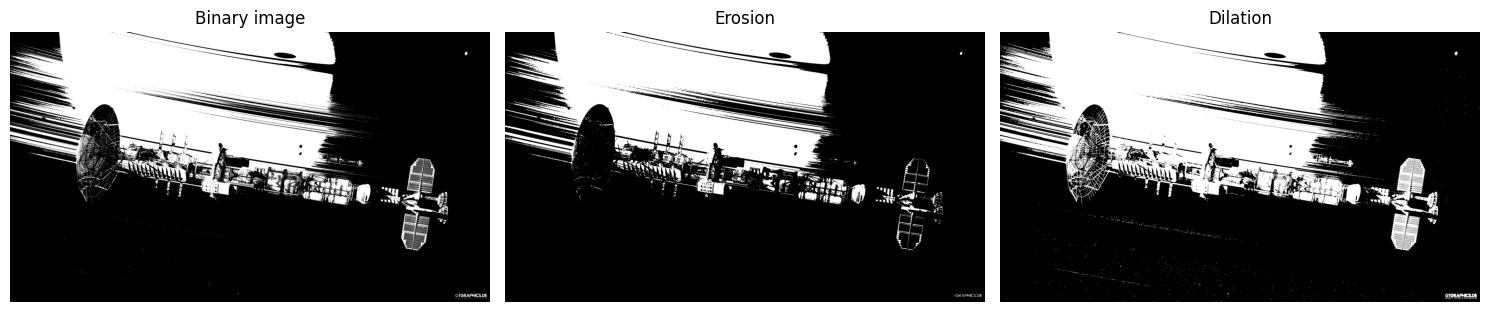

In [92]:
# Show binary morphology results side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary_image, cmap="gray")
axes[0].set_title("Binary image")
axes[0].axis("off")

axes[1].imshow(eroded_image, cmap="gray")
axes[1].set_title("Erosion")
axes[1].axis("off")

axes[2].imshow(dilated_image, cmap="gray")
axes[2].set_title("Dilation")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 11: Einfaches Template Matching

Beim Template Matching wird ein kleiner Bildausschnitt in einem größeren Bild gesucht. OpenCV vergleicht das Template an vielen Positionen mit dem Quellbild und berechnet eine Ähnlichkeit.

Der beste Treffer ist die Position mit dem höchsten Matching-Wert. Template Matching ist einfach zu verstehen, aber empfindlich gegen Skalierung und Rotation, weil das Template in derselben Größe und Ausrichtung gesucht wird.

In [93]:
# Select a small template region manually from the grayscale image.
template_top = height // 3
template_left = width // 3
template_height = 80
template_width = 80

template = image_gray[
    template_top:template_top + template_height,
    template_left:template_left + template_width,
]

# Search the template in the grayscale image.
match_result = cv2.matchTemplate(image_gray, template, cv2.TM_CCOEFF_NORMED)
_, max_score, _, max_location = cv2.minMaxLoc(match_result)

match_top_left = max_location
match_bottom_right = (
    match_top_left[0] + template_width,
    match_top_left[1] + template_height,
)

# Draw the detected match on a copy of the RGB image.
matched_image = image_rgb.copy()
cv2.rectangle(matched_image, match_top_left, match_bottom_right, (255, 0, 0), 2)

print(f"Matching score: {max_score:.3f}")
print(f"Detected top-left position: {match_top_left}")

Matching score: 1.000
Detected top-left position: (1280, 720)


Die folgenden Bilder zeigen zuerst das verwendete Template und danach das RGB-Bild mit markierter Trefferposition.

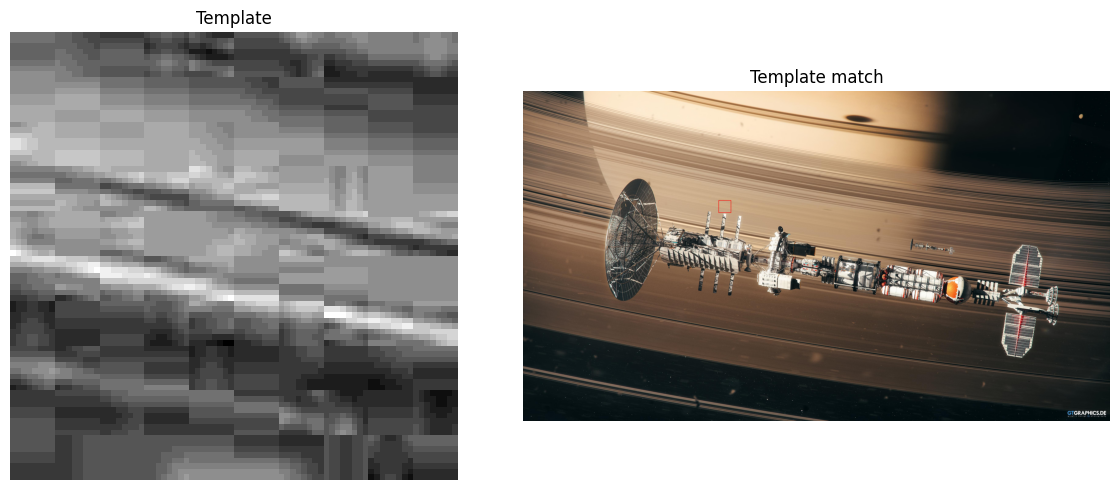

In [94]:
# Show template and detected match.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(template, cmap="gray")
axes[0].set_title("Template")
axes[0].axis("off")

axes[1].imshow(matched_image)
axes[1].set_title("Template match")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 12: Harris Corner Detection

Ecken sind Bildstellen, an denen sich die Helligkeit in mehrere Richtungen stark ändert. Solche Punkte sind wichtige Merkmale, weil sie oft gut wiedererkennbar sind.

Harris Corner Detection bewertet für jeden Bildbereich, ob dort starke Intensitätsänderungen in mehreren Richtungen auftreten. Ecken sind deshalb oft nützlich für Matching und Tracking, auch wenn diese Schritte hier noch nicht umgesetzt werden.

In [95]:
# Prepare grayscale image for Harris Corner Detection.
gray_float = np.float32(image_gray)

# Apply Harris Corner Detection with simple parameters.
harris_response = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)
harris_response = cv2.dilate(harris_response, None)

# Mark strong corner responses in red on a copy of the RGB image.
harris_image = image_rgb.copy()
corner_threshold = 0.01 * harris_response.max()
harris_image[harris_response > corner_threshold] = [255, 0, 0]

Die folgenden Bilder zeigen das originale RGB-Bild und dieselbe Szene mit rot markierten Harris-Ecken.

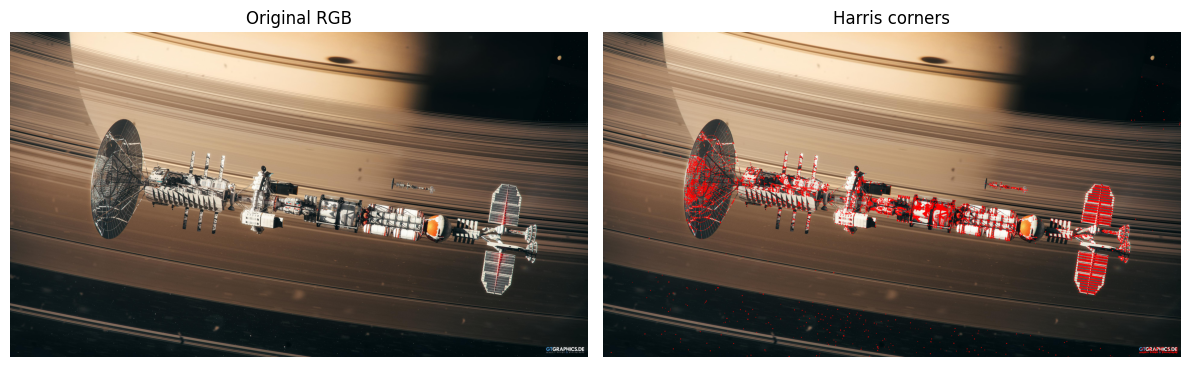

In [96]:
# Show original RGB image and Harris corner result side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(harris_image)
axes[1].set_title("Harris corners")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 13: Shi-Tomasi Corner Detection

Shi-Tomasi Corner Detection sucht starke und stabile Ecken im Bild. Wie bei Harris sind Ecken Bildstellen, an denen sich die Helligkeit in mehreren Richtungen deutlich ändert.

Der Unterschied ist, dass Shi-Tomasi eine andere Bewertungsregel für Ecken verwendet und dadurch gezielt gute Features auswählt. Solche Corner Features sind nützlich für Tracking und Matching, auch wenn diese Schritte hier nicht umgesetzt werden.

In [ ]:
# Detect strong corners with Shi-Tomasi Corner Detection.
# A simple central mask avoids detecting mostly small background stars.
shi_tomasi_mask = np.zeros_like(image_gray, dtype=np.uint8)
roi_top = height // 4
roi_bottom = 3 * height // 4
roi_left = width // 8
roi_right = 7 * width // 8
shi_tomasi_mask[roi_top:roi_bottom, roi_left:roi_right] = 255

shi_tomasi_corners = cv2.goodFeaturesToTrack(
    image_gray,
    maxCorners=50,
    qualityLevel=0.005,
    minDistance=20,
    mask=shi_tomasi_mask,
    blockSize=5,
)

# Draw detected corners as clearly visible circles on a copy of the RGB image.
shi_tomasi_image = image_rgb.copy()
corner_count = 0 if shi_tomasi_corners is None else len(shi_tomasi_corners)
marker_radius = 14

if shi_tomasi_corners is not None:
    for corner in shi_tomasi_corners:
        x, y = corner.ravel().astype(int)
        cv2.circle(shi_tomasi_image, (x, y), marker_radius, (255, 255, 255), 4)
        cv2.circle(shi_tomasi_image, (x, y), marker_radius - 5, (255, 0, 0), -1)

print(f"Number of detected Shi-Tomasi corners: {corner_count}")

Die folgenden Bilder zeigen das originale RGB-Bild und die Shi-Tomasi-Ecken als deutlich sichtbare rote Kreise. Die Suche wird hier einfach auf den mittleren Bildbereich begrenzt, damit vor allem relevante Objektpunkte statt kleiner Hintergrundpunkte markiert werden.

In [ ]:
# Show original RGB image and Shi-Tomasi corner result side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(shi_tomasi_image)
axes[1].set_title("Shi-Tomasi corners")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Aufgabe 14: Einfacher Lucas-Kanade Optical Flow

Optical Flow beschreibt die geschätzte Bewegung von Bildpunkten zwischen zwei Frames. Hier wird kein echtes Video verwendet, sondern ein zweiter Frame durch eine kleine künstliche Verschiebung des Grauwertbildes erzeugt.

Lucas-Kanade Optical Flow verfolgt ausgewählte Punkte in einer kleinen Umgebung. Das Verfahren nimmt an, dass sich die Punkte zwischen zwei Bildern nur wenig bewegen. Ecken eignen sich dafür besonders gut, weil sie lokal gut wiedererkennbar sind.

In [ ]:
# Create a second artificial frame by translating the grayscale image.
shift_x = 18
shift_y = 12
translation_matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
frame1_gray = image_gray.copy()
frame2_gray = cv2.warpAffine(image_gray, translation_matrix, (width, height))

# Use a simple central mask so most tracked points are on the main object.
flow_mask = np.zeros_like(frame1_gray, dtype=np.uint8)
roi_top = height // 4
roi_bottom = 3 * height // 4
roi_left = width // 8
roi_right = 7 * width // 8
flow_mask[roi_top:roi_bottom, roi_left:roi_right] = 255

# Detect Shi-Tomasi corners in the first frame.
flow_points = cv2.goodFeaturesToTrack(
    frame1_gray,
    maxCorners=50,
    qualityLevel=0.01,
    minDistance=20,
    mask=flow_mask,
    blockSize=5,
)

# Track the points from the first frame to the second frame.
next_points, status, error = cv2.calcOpticalFlowPyrLK(
    frame1_gray,
    frame2_gray,
    flow_points,
    None,
    winSize=(21, 21),
    maxLevel=2,
)

# Keep successfully tracked points and remove obvious outliers for this artificial translation.
tracked_old = flow_points[status == 1]
tracked_new = next_points[status == 1]
displacements = tracked_new - tracked_old
expected_displacement = np.array([shift_x, shift_y], dtype=np.float32)
vector_error = np.linalg.norm(displacements - expected_displacement, axis=1)
valid_vectors = vector_error < 4.0

tracked_old = tracked_old[valid_vectors]
tracked_new = tracked_new[valid_vectors]
displacements = displacements[valid_vectors]
mean_displacement = displacements.mean(axis=0) if len(displacements) > 0 else np.array([0, 0])

# Draw motion vectors on a copy of the RGB image.
flow_visualization = image_rgb.copy()

for old_point, new_point in zip(tracked_old, tracked_new):
    old_x, old_y = old_point.ravel().astype(int)
    new_x, new_y = new_point.ravel().astype(int)
    cv2.arrowedLine(flow_visualization, (old_x, old_y), (new_x, new_y), (0, 255, 255), 3, tipLength=0.35)
    cv2.circle(flow_visualization, (old_x, old_y), 5, (0, 0, 255), -1)
    cv2.circle(flow_visualization, (new_x, new_y), 5, (255, 0, 0), -1)

print(f"Number of successfully tracked points: {len(tracked_new)}")
print(f"Expected displacement: dx={shift_x}, dy={shift_y}")
print(f"Mean measured displacement: dx={mean_displacement[0]:.1f}, dy={mean_displacement[1]:.1f}")

Die folgenden Bilder zeigen den ersten Frame, den künstlich verschobenen zweiten Frame und die geschätzten Bewegungsvektoren. Da die Verschiebung künstlich ist, sollten die meisten Pfeile ungefähr gleich lang sein und in dieselbe Richtung zeigen. Starke Abweichungen wären hier eher schlechte Tracks.

In [ ]:
# Show both frames and the sparse optical flow visualization.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(frame1_gray, cmap="gray")
axes[0].set_title("Frame 1")
axes[0].axis("off")

axes[1].imshow(frame2_gray, cmap="gray")
axes[1].set_title("Frame 2")
axes[1].axis("off")

axes[2].imshow(flow_visualization)
axes[2].set_title("Lucas-Kanade flow")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Results

Das Bild aus dem `data`-Ordner wurde mit OpenCV geladen. Für die Anzeige mit `matplotlib` wurde es von BGR nach RGB konvertiert.

Zusätzlich wurden Höhe, Breite, Anzahl der Farbkanäle und Datentyp des Bildarrays ausgegeben. Danach wurde ein einzelner Pixel aus der Bildmitte ausgelesen und als BGR-Wert betrachtet.

Das Farbbild wurde in ein Grauwertbild umgewandelt und mit `cmap="gray"` angezeigt. Anschließend wurde ein Grauwert-Histogramm mit 256 Bins für den Intensitätsbereich von 0 bis 255 erstellt.

Danach wurde ein fester Schwellwert auf das Grauwertbild angewendet. Daraus entstanden ein normales Binärbild und ein inverses Binärbild. Außerdem wurden Gaussian Blur und Median Blur auf das Grauwertbild angewendet.

Anschließend wurden einfache Kanten mit Sobel in x- und y-Richtung sowie mit Canny erkannt. Danach wurden externe Konturen im Binärbild gefunden und auf einer Kopie des RGB-Bildes eingezeichnet.

Danach wurden Erosion und Dilatation mit einem einfachen 3x3-Kernel auf das Binärbild angewendet. Außerdem wurde ein kleiner Bildausschnitt als Template im Grauwertbild gesucht und der beste Treffer im RGB-Bild markiert.

Danach wurden Ecken mit Harris und Shi-Tomasi erkannt. Zum Schluss wurde ein zweiter künstlich verschobener Frame erstellt und die Bewegung ausgewählter Punkte mit Lucas-Kanade Optical Flow visualisiert.

## Interpretation

Bei der Anzeige ist die Farbreihenfolge wichtig: OpenCV arbeitet bei Farbbildern mit BGR, `matplotlib` erwartet RGB. Deshalb muss ein geladenes OpenCV-Farbbild vor der Darstellung umgewandelt werden.

Die Bildstruktur zeigt, dass ein Farbbild als mehrdimensionales Array mit drei Kanälen vorliegt. Der Beispielpixel bestätigt diese drei Farbwerte in der Reihenfolge Blau, Grün und Rot.

Das Grauwertbild hat nur noch einen Kanal. Dieser eine Wert beschreibt die Helligkeit des jeweiligen Pixels, weshalb keine getrennten Farbkanäle mehr notwendig sind. Im Histogramm zeigen hohe Balken, welche Helligkeitswerte besonders häufig im Bild vorkommen. Werte nahe 0 stehen für dunkle Bildbereiche, Werte nahe 255 für helle Bildbereiche.

Bei der Schwellwertbildung werden Pixel nur noch in zwei Klassen eingeteilt. Im normalen Binärbild werden helle Bereiche als weiß dargestellt und können als Vordergrund interpretiert werden. Im inversen Binärbild ist es umgekehrt: dunkle Bereiche werden weiß und können dadurch als Vordergrund markiert werden.

Die Glättungsfilter zeigen, wie Bildrauschen reduziert werden kann. Gaussian Blur macht Helligkeitsübergänge weicher, während Median Blur einzelne Ausreißer in der Nachbarschaft besser entfernen kann.

Die Kantenerkennung macht starke Intensitätswechsel sichtbar. Sobel zeigt diese Änderungen richtungsabhängig, während Canny eine klarere binäre Kantenkarte liefert. Konturen folgen zusammenhängenden Objektgrenzen und können deshalb einfache Objektumrisse beschreiben.

Morphologische Operationen bearbeiten die weißen Vordergrundbereiche im Binärbild. Erosion verkleinert diese Bereiche und kann kleine weiße Rauschpunkte entfernen, während Dilatation sie vergrößert. Template Matching sucht einen bekannten Bildausschnitt im Bild und ist besonders empfindlich, wenn sich Größe oder Rotation des gesuchten Musters ändern.

Harris Corner Detection markiert Punkte, an denen sich Intensitäten in mehreren Richtungen stark ändern. Shi-Tomasi wählt aus solchen Punkten besonders starke und stabile Ecken aus. Lucas-Kanade Optical Flow nutzt solche Punkte, um kleine Bewegungen zwischen zwei Frames zu schätzen.

## Conclusion

Das Bild wurde geladen, korrekt angezeigt, in seiner Grundstruktur untersucht, als Grauwertbild dargestellt, mit einem Histogramm analysiert, mit einfacher Schwellwertbildung segmentiert, mit einfachen Filtern geglättet, mit grundlegender Kantenerkennung ausgewertet, mit einfacher Konturerkennung erweitert, mit Erosion sowie Dilatation morphologisch bearbeitet, mit einfachem Template Matching untersucht, mit Harris sowie Shi-Tomasi auf Ecken analysiert und mit einfachem Lucas-Kanade Optical Flow visualisiert. Dense Optical Flow, Farneback Flow, Objekttracking-Systeme, Kalman-Filter, SLAM und weitere Verarbeitungsschritte folgen erst in späteren Aufgaben.

Ä, Ö und Ü werden hier nur als kurze Kodierungsprüfung genannt.